# ENTRENANDO MODELO DE ML PARA PREDECIR PRECIO DE AUTO USADO
## DATASET: NEOAUTO

# PASO 1 - INSTALAMOS E IMPORTAMOS LIBRERIAS

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set(style='whitegrid',context='notebook')

# PASO 2 CARGAMOS EL DATASET

In [3]:
df = pd.read_csv('/content/autos_clean_2.csv')
df

,fuel,price,year,subcategory,transmission
0,Gasolina,10900.0,2021,sedan,mecanica
1,Gasolina,19900.0,2020,camioneta,automatica
2,Gasolina,15900.0,2018,camioneta,automatica
3,Gasolina,27990.0,2024,camioneta,automatica
4,Gasolina,7900.0,2015,sedan,mecanica
...,...,...,...,...,...
1258,Gasolina,16500.0,2023,camioneta,automatica
1259,Dual,14800.0,2022,camioneta,automatica
1260,Gasolina,17500.0,2020,camioneta,automatica
1261,Gasolina,50000.0,2021,sedan,automatica


## PASO 3 - PREPROCESAMIENTO DE VARIABLES NÚMERICAS

In [4]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [5]:
df_cleaned = remove_outliers(df,'price')
df_cleaned

,fuel,price,year,subcategory,transmission
0,Gasolina,10900.0,2021,sedan,mecanica
1,Gasolina,19900.0,2020,camioneta,automatica
2,Gasolina,15900.0,2018,camioneta,automatica
3,Gasolina,27990.0,2024,camioneta,automatica
4,Gasolina,7900.0,2015,sedan,mecanica
...,...,...,...,...,...
1257,Gasolina,5500.0,1998,sedan,mecanica
1258,Gasolina,16500.0,2023,camioneta,automatica
1259,Dual,14800.0,2022,camioneta,automatica
1260,Gasolina,17500.0,2020,camioneta,automatica


# PASO 4: CODIFICACIÓN DE VARIABLES CATEGORICAS CON SKLEARN

## 4.1 IDENTIFICAMOS VARIABLES CATEGORICAS

In [6]:
categorical_columns = df.select_dtypes(object).columns
categorical_columns

Index(['fuel', 'subcategory', 'transmission'], dtype='object')

## 4.2 CREAMOS LISTA POR TIPO DE CODIFICACIÓN

In [7]:
for cc in categorical_columns:
  print("*"*50)
  print(df[cc].value_counts())

**************************************************
fuel
Gasolina    1099
Dual         164
Name: count, dtype: int64
**************************************************
subcategory
camioneta    923
sedan        340
Name: count, dtype: int64
**************************************************
transmission
automatica    865
mecanica      398
Name: count, dtype: int64


## 4.3 DIVIDO LAS VARIABLES POR TIOP DE CODIFICACIÓN(LABEL Y ONE HOT ENCODING)

In [8]:
ordinal_cols = ['fuel','subcategory','transmission']
onehot_cols = list(set(categorical_columns) - set(ordinal_cols))
print(ordinal_cols,onehot_cols)

['fuel', 'subcategory', 'transmission'] []


## 4.4 CODIFICAMOS USANDO LOS MODULSO COMPOSE Y PREPROCESSING DE SKLEARN

In [9]:
import sklearn.compose
import sklearn.preprocessing

### 4.4.1 CREAMOS UN TRANSFORMER

In [10]:
transformer = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OrdinalEncoder(),ordinal_cols),
    (sklearn.preprocessing.OneHotEncoder(),onehot_cols),
    remainder='passthrough'
)
transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('ordinalencoder', OrdinalEncoder(),
                                 ['fuel', 'subcategory', 'transmission']),
                                ('onehotencoder', OneHotEncoder(), [])])

### 4.4.2 APLICAMOS EL TRANSFOMER A EL DATASET

In [11]:
data_transformed_df = (
    pd.DataFrame(
        transformer.fit_transform(df),
        columns = transformer.get_feature_names_out(),
        index=df.index
    )
)
data_transformed_df

,ordinalencoder__fuel,ordinalencoder__subcategory,ordinalencoder__transmission,remainder__price,remainder__year
0,1.0,1.0,1.0,10900.0,2021.0
1,1.0,0.0,0.0,19900.0,2020.0
2,1.0,0.0,0.0,15900.0,2018.0
3,1.0,0.0,0.0,27990.0,2024.0
4,1.0,1.0,1.0,7900.0,2015.0
...,...,...,...,...,...
1258,1.0,0.0,0.0,16500.0,2023.0
1259,0.0,0.0,0.0,14800.0,2022.0
1260,1.0,0.0,0.0,17500.0,2020.0
1261,1.0,1.0,0.0,50000.0,2021.0


In [12]:
data_transformed_df = data_transformed_df.rename(
    columns=lambda x: x.replace("ordinalencoder__", "").replace("onehotencoder__", "").replace("remainder__", "")
)

data_transformed_df

,fuel,subcategory,transmission,price,year
0,1.0,1.0,1.0,10900.0,2021.0
1,1.0,0.0,0.0,19900.0,2020.0
2,1.0,0.0,0.0,15900.0,2018.0
3,1.0,0.0,0.0,27990.0,2024.0
4,1.0,1.0,1.0,7900.0,2015.0
...,...,...,...,...,...
1258,1.0,0.0,0.0,16500.0,2023.0
1259,0.0,0.0,0.0,14800.0,2022.0
1260,1.0,0.0,0.0,17500.0,2020.0
1261,1.0,1.0,0.0,50000.0,2021.0


In [13]:
data_transformed_df.dtypes

,0
fuel,float64
subcategory,float64
transmission,float64
price,float64
year,float64


In [14]:
data_transformed_df

,fuel,subcategory,transmission,price,year
0,1.0,1.0,1.0,10900.0,2021.0
1,1.0,0.0,0.0,19900.0,2020.0
2,1.0,0.0,0.0,15900.0,2018.0
3,1.0,0.0,0.0,27990.0,2024.0
4,1.0,1.0,1.0,7900.0,2015.0
...,...,...,...,...,...
1258,1.0,0.0,0.0,16500.0,2023.0
1259,0.0,0.0,0.0,14800.0,2022.0
1260,1.0,0.0,0.0,17500.0,2020.0
1261,1.0,1.0,0.0,50000.0,2021.0


In [15]:
data_transformed_df.to_csv('autos_transformed.csv',index=None)

In [16]:
data_transformed_df = pd.read_csv('/content/autos_transformed.csv')
data_transformed_df

,fuel,subcategory,transmission,price,year
0,1.0,1.0,1.0,10900.0,2021.0
1,1.0,0.0,0.0,19900.0,2020.0
2,1.0,0.0,0.0,15900.0,2018.0
3,1.0,0.0,0.0,27990.0,2024.0
4,1.0,1.0,1.0,7900.0,2015.0
...,...,...,...,...,...
1258,1.0,0.0,0.0,16500.0,2023.0
1259,0.0,0.0,0.0,14800.0,2022.0
1260,1.0,0.0,0.0,17500.0,2020.0
1261,1.0,1.0,0.0,50000.0,2021.0


In [142]:
data_transformed_df['price']  = data_transformed_df['price'] / 1000

# PASO 5 - CORRELACIONES

In [17]:
corr_matrix = data_transformed_df.corr()
corr_charges = corr_matrix['price']
corr_charges.sort_values(ascending=False)

,price
price,1.000000
year,0.398157
fuel,0.224872
subcategory,-0.283188
transmission,-0.334362


<Axes: >

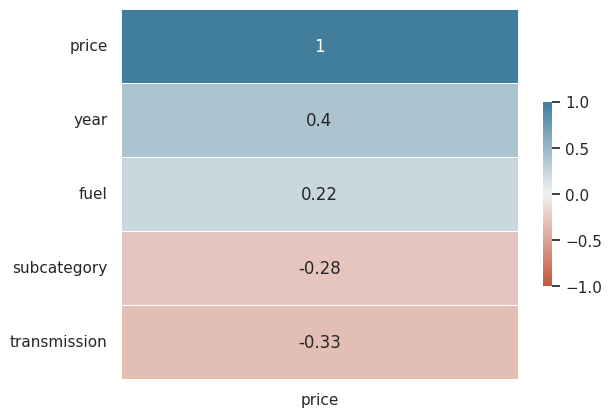

In [18]:
sns.heatmap(
    data=corr_charges.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

## PASO 6 - IDENTIFICAMOS VARIABLE X y Y , dividmos en train test

In [19]:
cols = corr_charges.index.tolist()
cols.remove('price')
cols

['fuel', 'subcategory', 'transmission', 'year']

In [20]:
X = data_transformed_df[cols].values
y = data_transformed_df['price'].values.reshape(-1,1)

In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30,random_state=42)

# CREAMOS UN CODIGO PARA PODER EVALUAR VARIOS MODELOS

## 1 - IMPORTAMOS LIBRERIAS

In [22]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler,MinMaxScaler

## 2 - ESCALAMIENTO DE DATOS

In [23]:
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

## 3 - CREAMOS DICCIONARIO DE MODELOS

In [24]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(alpha=0.1),
    "Ridge": Ridge(alpha=1.0),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=10),
    "SVR": SVR(kernel='rbf'),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42)
}

## 4 - CREAMOS BUCLE PARA PROBAR CADA MODELO DEL DICCIONARIO

In [25]:
results = {}
for name,model in models.items():

  if name in ['SVR','Random Forest Regressor']:
    model.fit(X_train_scaled,y_train_scaled.ravel())
  else:
    model.fit(X_train_scaled,y_train_scaled)

  y_pred_scaled = model.predict(X_test_scaled)

  r2 = r2_score(y_test_scaled, y_pred_scaled)
  mse = mean_squared_error(y_test_scaled, y_pred_scaled)
  mae = mean_absolute_error(y_test_scaled, y_pred_scaled)
  results[name] = {"R2": r2, "MSE": mse, "MAE": mae}

# MOSTRAMOS RESULTADOS DE LOS MODELOS ENTRENADOS

In [26]:
results_df = pd.DataFrame(results).T
print("Model Comparison:")
display(results_df)

Model Comparison:


,R2,MSE,MAE
Linear Regression,0.281318,0.841242,0.584340
Lasso,0.238859,0.890942,0.595384
Ridge,0.281242,0.841332,0.584352
KNN Regressor,0.346069,0.765450,0.565281
SVR,0.287271,0.834274,0.506759
Random Forest Regressor,0.352151,0.758330,0.551245


# BUSCAMOS EL MEJOR MODELO

In [27]:
best_r2_model = results_df['R2'].idxmax()
best_mse_model = results_df['MSE'].idxmin()
print(f"\nBest model based on R2: {best_r2_model} (R2: {results_df.loc[best_r2_model, 'R2']:.4f})")
print(f"Best model based on MSE: {best_mse_model} (MSE: {results_df.loc[best_mse_model, 'MSE']:.2f})")


Best model based on R2: Random Forest Regressor (R2: 0.3522)
Best model based on MSE: Random Forest Regressor (MSE: 0.76)


# GRAFICAMOS RESULTADOS

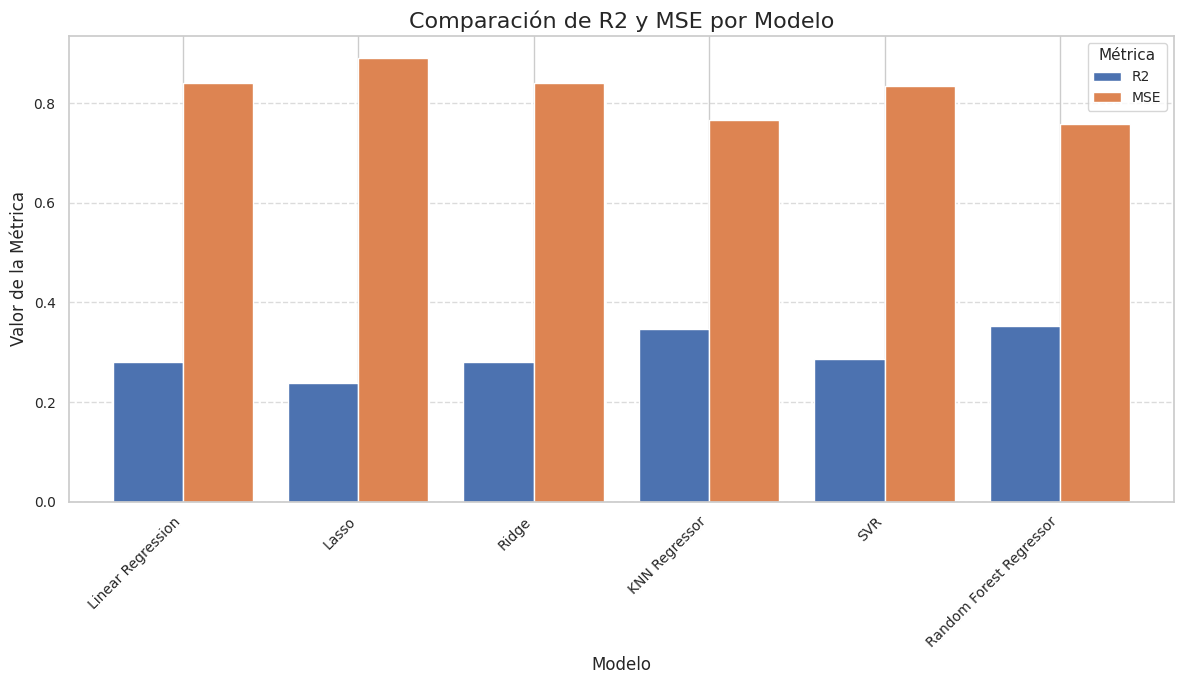

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo las métricas R2 y MSE para comparar
results_to_plot = results_df[['R2', 'MSE']]

# Crear el gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(12, 7))
results_to_plot.plot(kind='bar', ax=ax, width=0.8)

plt.title('Comparación de R2 y MSE por Modelo', fontsize=16)
plt.ylabel('Valor de la Métrica', fontsize=12)
plt.xlabel('Modelo', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Métrica', fontsize=10, title_fontsize='11')
plt.tight_layout()
plt.show()